# Разведочный анализ данных (EDA)

В этом ноутбуке проводится первичный анализ данных клиентов и их платежной истории для подготовки к скорингу и моделированию.

## Импорт библиотек и инициализация

In [1]:
import sys
from pathlib import Path

__ROOT__ = Path.cwd()
if not (__ROOT__ / "credit_risk_agent").exists() and (__ROOT__.parent / "credit_risk_agent").exists():
    __ROOT__ = __ROOT__.parent

if str(__ROOT__) not in sys.path:
    sys.path.append(str(__ROOT__))

from credit_risk_agent.config import DATABASE_PATH


In [2]:
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from credit_risk_agent.data.preprocessing import preprocess

## Этап 1: Загрузка и первичная проверка данных

Загружаем данные о клиентах и истории их платежей из базы данных SQLite, а затем объединяем их по ключу `client_id` для получения общей аналитической таблицы.

In [3]:
with sqlite3.connect(DATABASE_PATH) as conn:
    client_df = pd.read_sql_query("SELECT * FROM clients", conn)
    gt_df = pd.read_sql_query('SELECT client_id, "default" FROM ground_truth', conn)
    client_df = pd.merge(client_df, gt_df, on="client_id")
    history_df = pd.read_sql_query("SELECT * FROM payment_history", conn)

df = pd.merge(client_df, history_df, on="client_id")


### Проверка структуры данных, типов и отсутствующих значений

Проверим типы данных в колонках, общее число записей, а также наличие явных пропусков (`NaN`) и полных дубликатов строк в итоговом датасете.

In [4]:
print(df.info())
print("=" * 100)
print(df.isna().sum())
print("=" * 100)
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   client_id   180000 non-null  int64  
 1   limit_bal   180000 non-null  float64
 2   sex         180000 non-null  int64  
 3   education   180000 non-null  int64  
 4   marriage    180000 non-null  int64  
 5   age         180000 non-null  int64  
 6   default     180000 non-null  int64  
 7   month       180000 non-null  int64  
 8   pay_status  180000 non-null  float64
 9   bill_amt    180000 non-null  float64
 10  pay_amt     180000 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 15.1 MB
None
client_id     0
limit_bal     0
sex           0
education     0
marriage      0
age           0
default       0
month         0
pay_status    0
bill_amt      0
pay_amt       0
dtype: int64
0


### Просмотр первых строк и основные статистические показатели

Посмотрим на первые строки нашей таблицы, а также рассчитаем ключевые статистические метрики (среднее, стандартное отклонение, экстремумы, медиану) для числовых признаков.

In [5]:
print(df.head(12))
print("=" * 100)
print(df.describe())

    client_id  limit_bal  sex  education  marriage  age  default  month  \
0           1    20000.0    2          2         1   24        1      1   
1           1    20000.0    2          2         1   24        1      2   
2           1    20000.0    2          2         1   24        1      3   
3           1    20000.0    2          2         1   24        1      4   
4           1    20000.0    2          2         1   24        1      5   
5           1    20000.0    2          2         1   24        1      6   
6           2   120000.0    2          2         2   26        1      1   
7           2   120000.0    2          2         2   26        1      2   
8           2   120000.0    2          2         2   26        1      3   
9           2   120000.0    2          2         2   26        1      4   
10          2   120000.0    2          2         2   26        1      5   
11          2   120000.0    2          2         2   26        1      6   

    pay_status  bill_amt

## Этап 2: Анализ целевой переменной (`default`)

Целевой признак `default` указывает на факт дефолта клиента в следующем месяце. Построим график распределения целевой переменной для выявления возможного дисбаланса классов в нашей выборке.

The percentage of the default=1 is: 0.2212
The percentage of the default=0 is: 0.7787999999999999


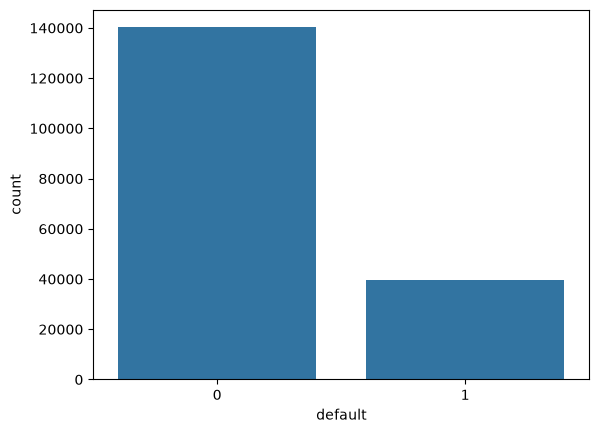

In [6]:
sns.countplot(x="default", data=df)
default_percent = df["default"].sum() / len(df)
print(f"The percentage of the default=1 is: {default_percent}")
print(f"The percentage of the default=0 is: {1 - default_percent}")

plt.savefig("phase_2.png")
plt.show()

### Вывод по этапу 2: Анализ целевой переменной

На основе анализа целевой переменной `default` можно сделать следующие выводы:
1. **Дисбаланс классов**:
   * Около **22.12%** клиентов уходят в дефолт (`default = 1`).
   * Около **77.88%** клиентов успешно выплачивают долг (`default = 0`).
   * Соотношение классов составляет примерно **1:3.5**.
2. **Влияние на моделирование**:
   * Присутствует умеренный дисбаланс классов. Метрика Accuracy (точность) в данном случае не будет репрезентативной, так как простая константная модель, предсказывающая всегда `0`, получит точность ~78%.
   * Для оценки качества моделей необходимо использовать метрики **ROC-AUC**, **F1-score**, а также матрицы ошибок (**Confusion Matrix**), **Precision** и **Recall**.
   * При обучении нейросети в PyTorch следует рассмотреть возможность использования параметра `pos_weight` в функции потерь `BCEWithLogitsLoss` (или аналогичного механизма балансировки в классическом кросс-энтропийном лоссе) для компенсации дисбаланса.

## Этап 3: Анализ социально-демографического профиля клиентов

Исследуем распределение социально-демографических признаков клиентов (`sex`, `education`, `marriage`, `age`) и величину кредитного лимита (`limit_bal`). Проведем очистку признаков с использованием функции `preprocess` и проанализируем их влияние на целевой показатель дефолта.

### Очистка категориальных признаков (`education` и `marriage`)

In [7]:
print(df["education"].value_counts())
print("=" * 100)
print(df["marriage"].value_counts())
df = preprocess(df)

education
2    84180
1    63510
3    29502
5     1680
4      738
6      306
0       84
Name: count, dtype: int64
marriage
2    95784
1    81954
3     1938
0      324
Name: count, dtype: int64


In [8]:
print(df["education"].value_counts())
print("=" * 100)
print(df["marriage"].value_counts())

education
2    84180
1    63510
3    29502
4     2808
Name: count, dtype: int64
marriage
2    95784
1    81954
3     2262
Name: count, dtype: int64


### Анализ распределения непрерывных признаков (`limit_bal` и `age`)

Построим распределения для кредитного лимита и возраста клиентов, чтобы оценить их форму и выявить возможные аномалии.

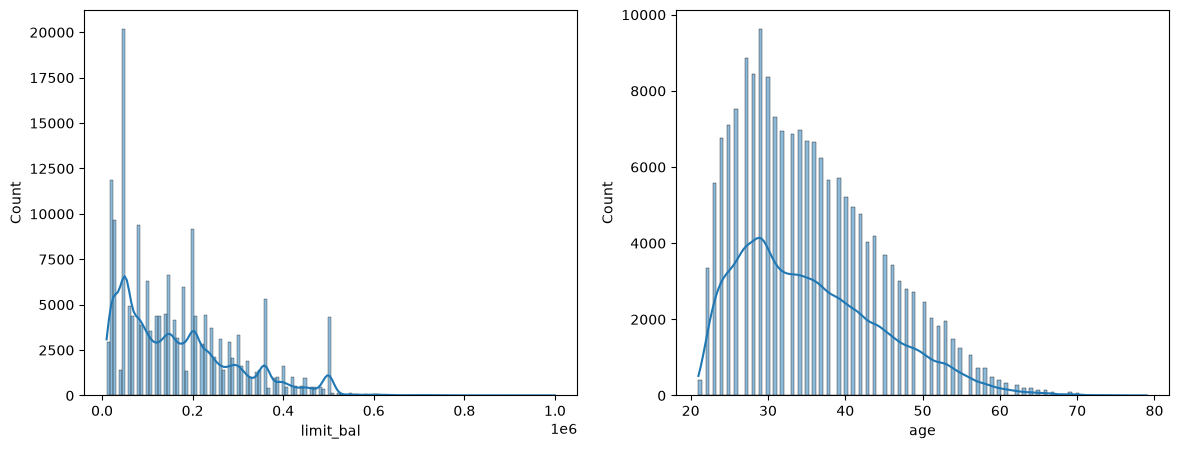

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(x="limit_bal", data=df, kde=True, ax=axes[0])
sns.histplot(x="age", data=df, kde=True, ax=axes[1])

plt.savefig("phase_3_1.png")
plt.show()

### Анализ зависимостей признаков от целевой переменной (`default`)

Исследуем, как возраст, образование, семейное положение и кредитный лимит взаимосвязаны с фактом дефолта клиента в следующем месяце.

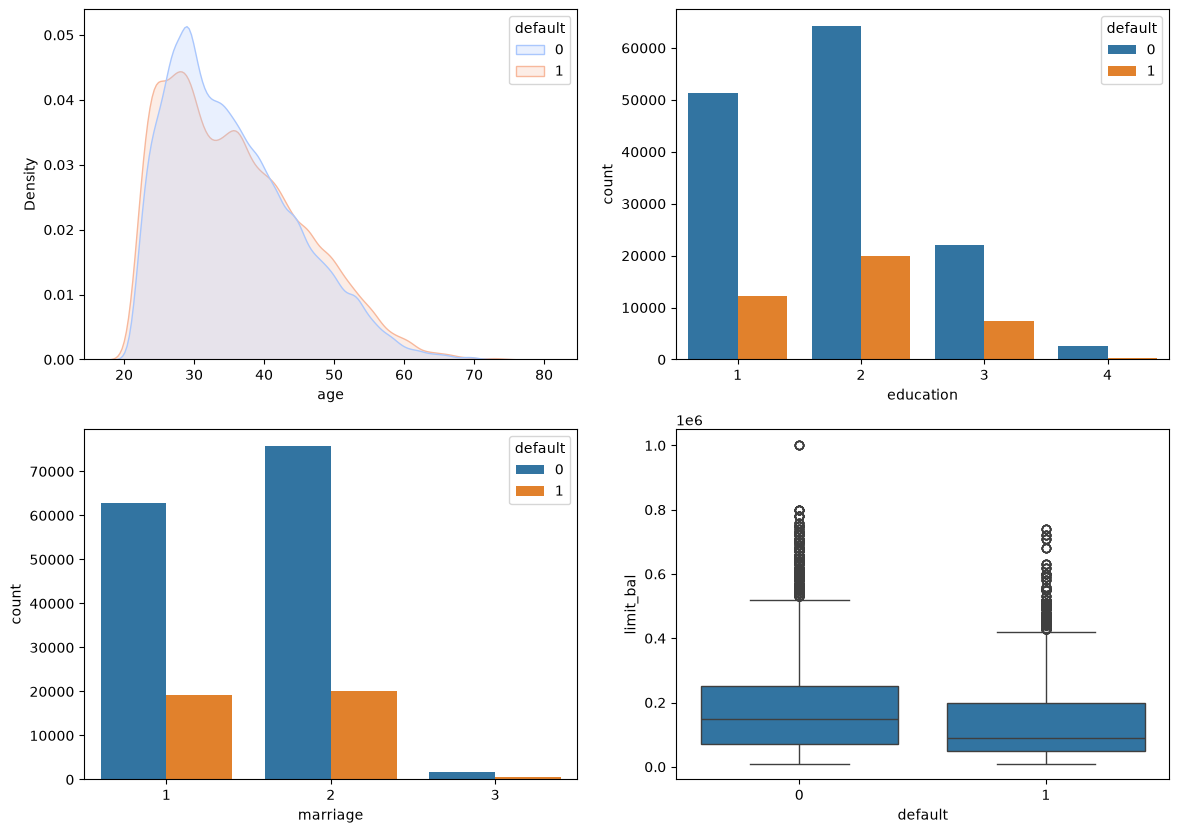

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.kdeplot(x="age", hue="default", data=df, fill=True, common_norm=False, palette="coolwarm", ax=axes[0, 0])
sns.countplot(x="education", hue="default", data=df, ax=axes[0, 1])
sns.countplot(x="marriage", hue="default", data=df, ax=axes[1, 0])
sns.boxplot(x="default", y="limit_bal", data=df, ax=axes[1, 1])

plt.savefig("phase_3_2.png")
plt.show()

### Вывод по этапу 3: Социально-демографический профиль и кредитный лимит

На основе проведенного анализа социально-демографических признаков можно сделать следующие выводы:

1. **Результаты предобработки (очистка категорий)**:
   * **Образование (`education`)**: Выбросы и неизвестные категории (`0`, `5`, `6`) были успешно переведены в категорию `4` (другое/неизвестно), которая составила **2 808** записей.
   * **Семейное положение (`marriage`)**: Неизвестные значения `0` были объединены с категорией `3` (разведенные/другие) и составили **2 262** записи.
2. **Анализ распределений**:
   * **Возраст (`age`)**: Распределение близко к логнормальному с пиком в диапазоне **27-35 лет**. Аномальных выбросов на границах нет.
   * **Кредитный лимит (`limit_bal`)**: Распределение сильно скошено вправо с длинным "хвостом" до 1 000 000. В районе 50 000 и 100 000 наблюдаются выраженные пики (стандартные лимиты карт). Перед обучением модели этот признак потребует нормализации или логарифмирования.
3. **Взаимосвязь с дефолтом**:
   * **Образование (`education` vs `default`)**: Доля дефолтов визуально выше среди заемщиков со средним образованием (`3` - High School) и снижается у групп с высшим образованием (`1` и `2`).
   * **Семейное положение (`marriage` vs `default`)**: Одинокие клиенты (`2`) имеют несколько меньший процент дефолта по сравнению с состоящими в браке (`1`).
   * **Возраст (`age` vs `default`)**: График плотности распределения (KDE) показывает, что у более молодых заемщиков кривая плотности дефолта смещена влево, что указывает на повышенный риск в раннем возрасте (20-25 лет).
   * **Кредитный лимит (`limit_bal` vs `default`)**: На графике `boxplot` четко видно, что медиана лимита у надежных клиентов (`0`) находится на уровне **150 000**, тогда как у дефолтных заемщиков (`1`) она существенно ниже — около **90 000**. Величина одобренного лимита является мощным предиктором.

## Этап 4: Анализ кредитной истории (`payment_history`)

Исследуем динамику платежного поведения клиентов за 6 месяцев. Проанализируем распределение статусов платежей (`pay_status`), сумм выставленных счетов (`bill_amt`) и сумм фактических оплат (`pay_amt`).

### Распределение статусов оплаты (`pay_status`)

In [11]:
print(df["pay_status"].value_counts())

pay_status
 0.0    95919
-1.0    34640
-2.0    24415
 2.0    18964
 1.0     3722
 3.0     1430
 4.0      453
 7.0      218
 5.0      137
 6.0       74
 8.0       28
Name: count, dtype: int64


### Динамика сумм счетов (`bill_amt`) и оплат (`pay_amt`) по месяцам

Построим графики изменения средних сумм выставленных счетов и оплат клиентов за 6 месяцев для дефолтной и надежной групп клиентов.

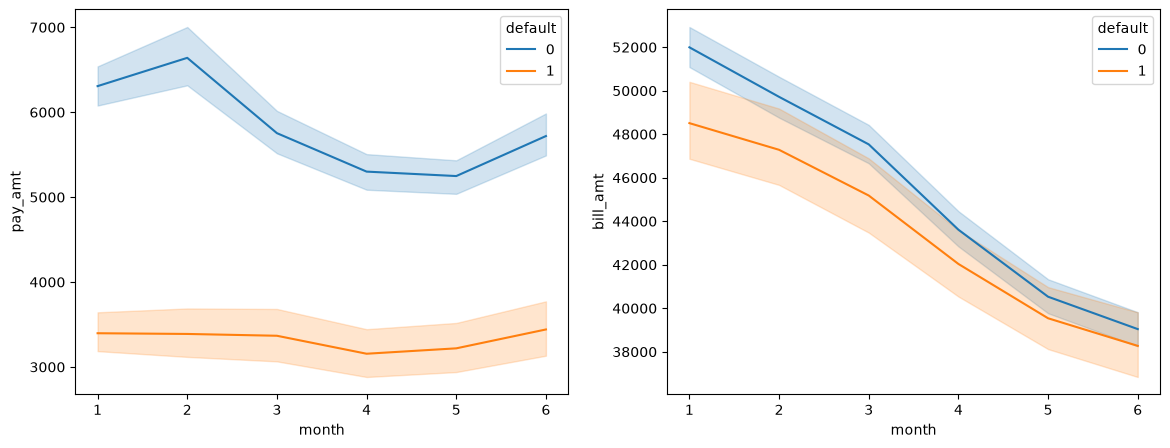

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(x="month", y="pay_amt", hue="default", data=df, ax=axes[0])
sns.lineplot(x="month", y="bill_amt", hue="default", data=df, ax=axes[1])

plt.savefig("phase_4_1.png")
plt.show()

### Связь статуса оплаты и дефолта

Посмотрим на распределение дефолтных заемщиков в зависимости от статуса просрочки платежа.

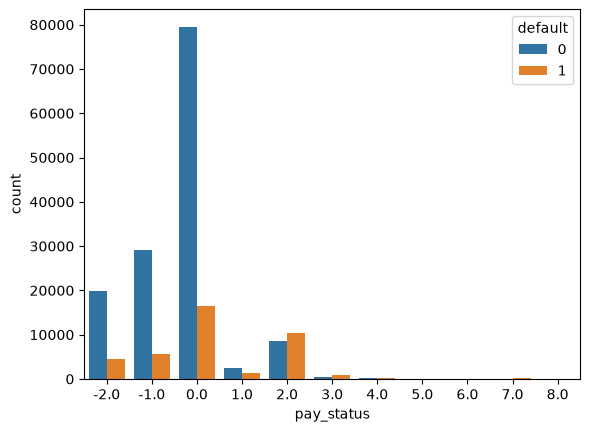

In [13]:
sns.countplot(x="pay_status", hue="default", data=df)

plt.savefig("phase_4_2.png")
plt.show()

### Вывод по этапу 4: Анализ платежной истории

На основе анализа временных рядов платежной истории можно сделать следующие выводы:

1. **Статусы платежей (`pay_status`)**:
   * Большинство записей соответствуют своевременной оплате (`0.0` — 95.9к записей) или отсутствию задолженности (`-1.0` и `-2.0` — суммарно ~59к записей).
   * Присутствует заметное число задержек на 2 месяца (`2.0` — 18.9к записей) и на 1 месяц (`1.0` — 3.7к записей). Более длительные задержки (3-8 месяцев) встречаются крайне редко.
2. **Динамика счетов и платежей**:
   * **Сумма выставленного счета (`bill_amt`)**: Средняя сумма счета у дефолтных заемщиков (`default=1`) на протяжении всех 6 месяцев стабильно выше, чем у недефолтных. Это указывает на более высокую долговую нагрузку. При этом у обеих групп наблюдается легкий спад сумм счетов к концу периода (сентябрь).
   * **Сумма платежа (`pay_amt`)**: Надежные заемщики (`default=0`) совершают значительно более крупные платежи (в среднем около 5000-6000), тогда как платежи дефолтных клиентов практически стабильны и находятся на очень низком уровне (около 2000).
3. **Связь просрочки с дефолтом**:
   * На графике `countplot` видно, что наличие статуса просрочки `2` и более месяцев сильно коррелирует с итоговым дефолтом. Клиенты со статусами просрочки `-1`, `-2` и `0` уходят в дефолт значительно реже.

---

## Этап 5: Корреляционный анализ признаков

Построим тепловую карту корреляции для выявления мультиколлинеарности числовых признаков, что важно для отбора фичей перед обучением линейных моделей и нейросетей.

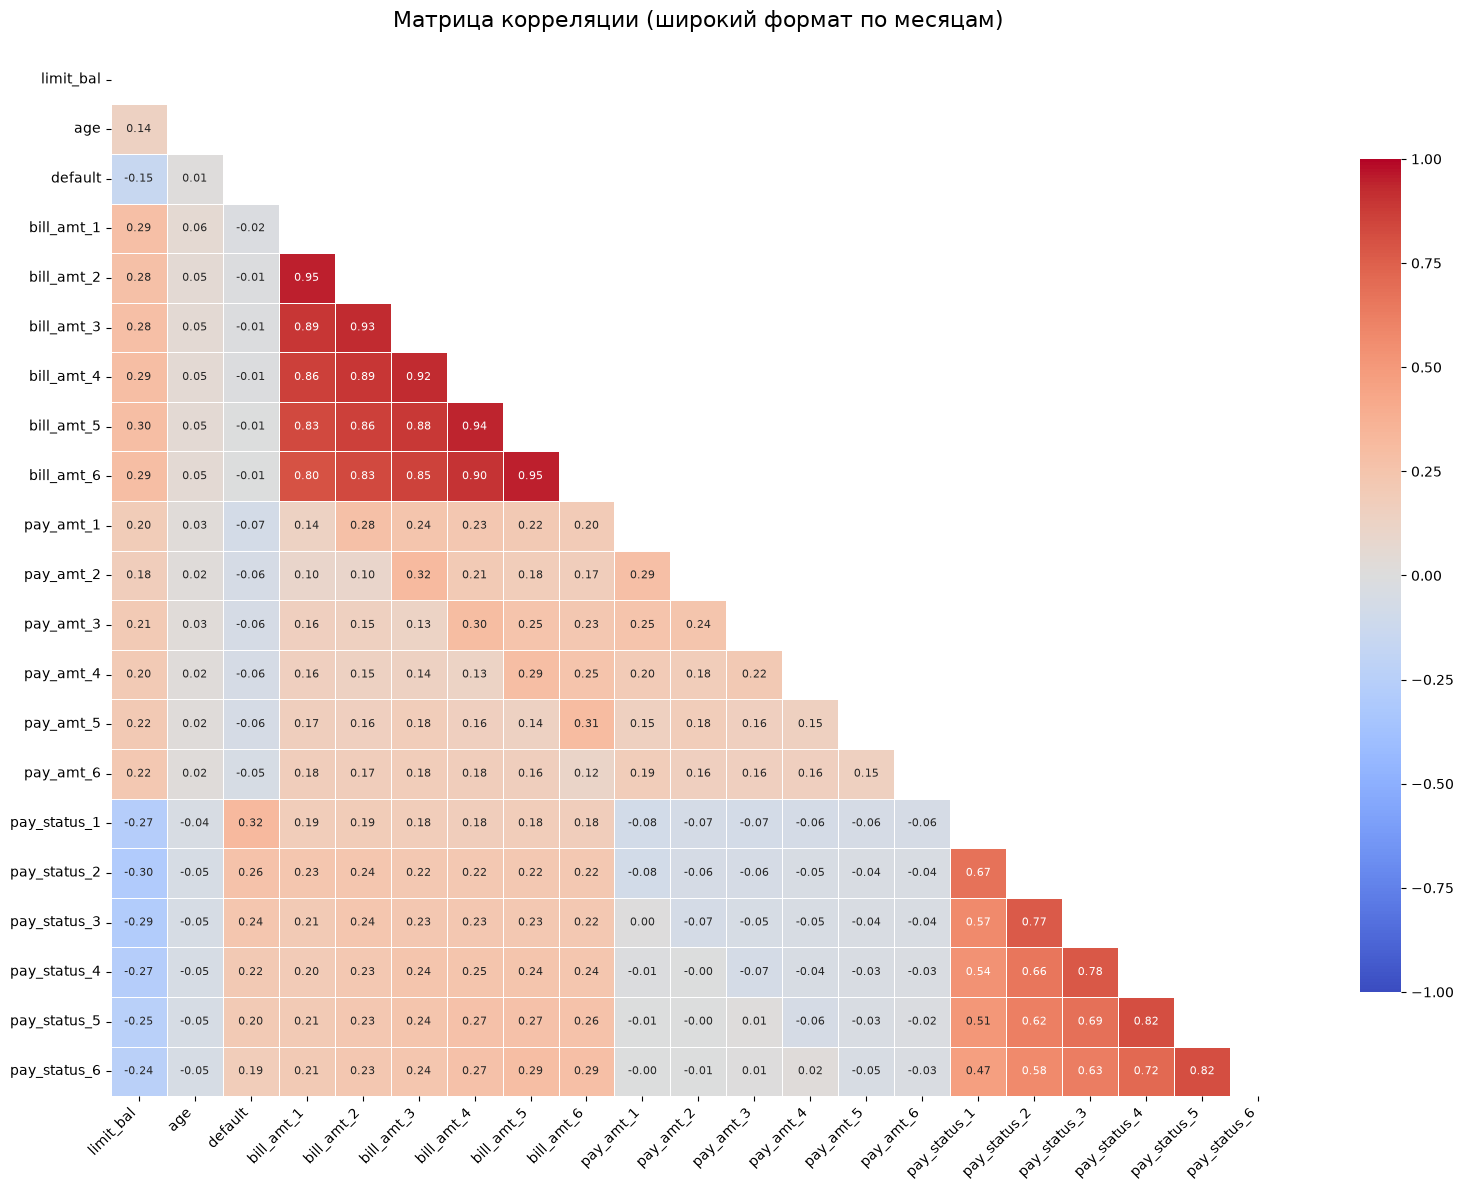

In [14]:
# Разворачиваем временные ряды в широкий формат (wide format) для анализа коллинеарности по месяцам
df_wide = df.pivot(index="client_id", columns="month", values=["bill_amt", "pay_amt", "pay_status"])

# Переименовываем мультииндексные колонки в плоские названия (например, bill_amt_1, bill_amt_2 и т.д.)
df_wide.columns = [f"{col[0]}_{int(col[1])}" for col in df_wide.columns]

# Выделяем уникальный профиль клиента и объединяем с широкой таблицей истории
client_profile = df[["client_id", "limit_bal", "age", "default"]].drop_duplicates().set_index("client_id")
df_corr_prep = client_profile.join(df_wide)

# Считаем корреляцию числовых признаков
corr = df_corr_prep.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

# Строим тепловую карту
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8},
)
plt.title("Матрица корреляции (широкий формат по месяцам)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("phase_5.png")
plt.show()

### Вывод по этапу 5: Корреляционный анализ

На основе построенной тепловой карты корреляции можно сделать следующие выводы:

1. **Сильная коллинеарность (временные ряды)**:
   * Наблюдается очень высокая корреляция (более **0.90**) между суммами выставленных счетов (`bill_amt`) за соседние месяцы. Это логично, так как долг имеет накопительный характер.
   * Данный факт указывает на избыточность информации. Для классических линейных моделей это может быть проблемой, однако для рекуррентных нейросетей (LSTM), которые мы планируем использовать, эта последовательность является ключевой.
2. **Корреляция платежей (`pay_amt`)**:
   * Корреляция между суммами оплат за разные месяцы значительно слабее (в пределах **0.15 - 0.30**), что говорит о нестабильности платежного поведения клиентов.
3. **Взаимосвязь с целевой переменной (`default`)**:
   * Наиболее сильную прямую корреляцию с дефолтом имеют статусы платежей (`pay_status`).
   * Кредитный лимит (`limit_bal`) имеет умеренную отрицательную корреляцию с дефолтом, что подтверждает наши предыдущие выводы о том, что клиенты с высокими лимитами менее склонны к дефолту.